In [1]:
import pandas as pd
import sys

In [2]:
sys.path.insert(0, '')
from Clase_Valor import Valor
from Transversal import leer_activos, leer_parametros, leer_configuracion

In [3]:
carpeta_input, cofre, seguimiento, saving_step = leer_parametros()
output_level = leer_configuracion()

In [4]:
df_activos = leer_activos(carpeta_input)
df_activos

Small batch 240812


,SIMBOLO,NOMBRE
0,BTC-USD,Bitcoin
1,NFLX,"Netflix, Inc."
2,FCEL,"FuelCell Energy, Inc."
3,DVA,DaVita Inc.
4,AAPL,AAPL


In [5]:
simbolo, nombre = 'TSLA', 'Tesla'

In [6]:
valor = Valor(simbolo, nombre, cofre) # Si no existe el objeto, se crea 
valor.extraer_data()
valor.ajustar_data()
df_rendimientos = valor.adj_data
df_rendimientos

TSLA.pkl ../Cofre/Valor/
[*********************100%***********************]  1 of 1 completed
Ejemplo funcional "date" con pandas nuevo


,Date,t,Open,High,Low,Close,Volume,rendimiento
0,2010-06-29,-4934,0.003056,0.004021,0.002821,0.003842,0.306605,NaN
1,2010-06-30,-4933,0.004148,0.004893,0.003748,0.003833,0.280640,-0.002511
2,2010-07-01,-4932,0.004021,0.004169,0.003260,0.003532,0.133184,-0.078473
3,2010-07-02,-4931,0.003699,0.003715,0.003009,0.003088,0.082560,-0.125683
4,2010-07-03,-4930,0.003579,0.003591,0.002893,0.002964,0.089659,-0.040234
...,...,...,...,...,...,...,...,...
5164,2024-08-18,230,0.518935,0.535396,0.513860,0.532019,0.086339,0.010077
5165,2024-08-19,231,0.523695,0.537954,0.516506,0.537326,0.081834,0.009976
5166,2024-08-20,232,0.542538,0.550595,0.529703,0.533418,0.079166,-0.007274
5167,2024-08-21,233,0.537206,0.542007,0.528014,0.538653,0.074940,0.009815


In [7]:
#df_rendimientos = df_rendimientos[df_rendimientos['Date'] >= "2020-01-01"]

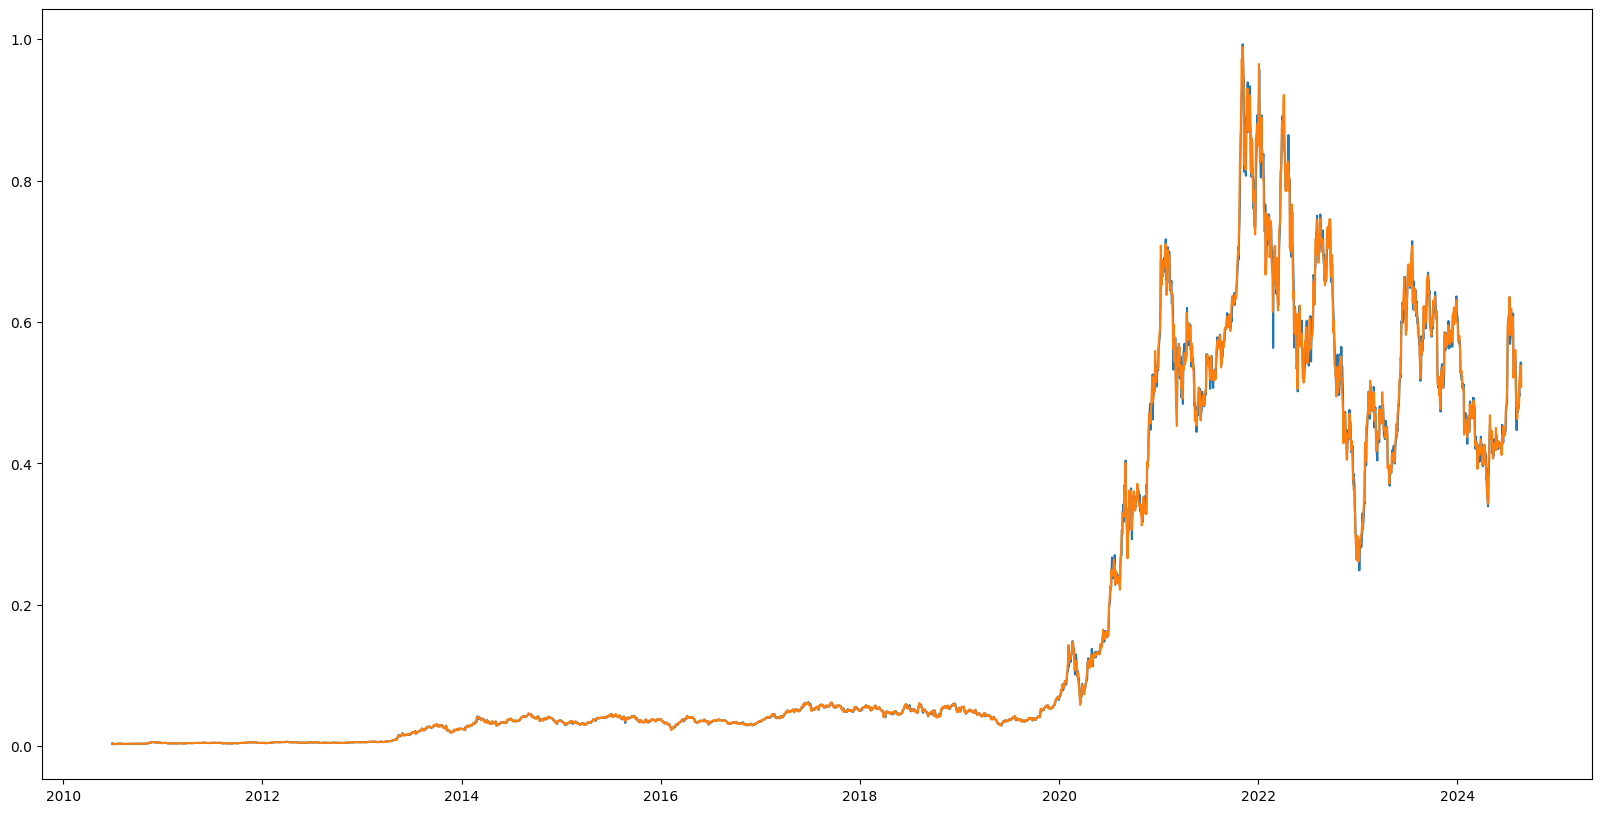

In [8]:
# graficar
import matplotlib.pyplot as plt
plt.figure(figsize = (20, 10))
plt.plot(df_rendimientos['Date'], df_rendimientos['Open'])
plt.plot(df_rendimientos['Date'], df_rendimientos['Close'])
plt.show()



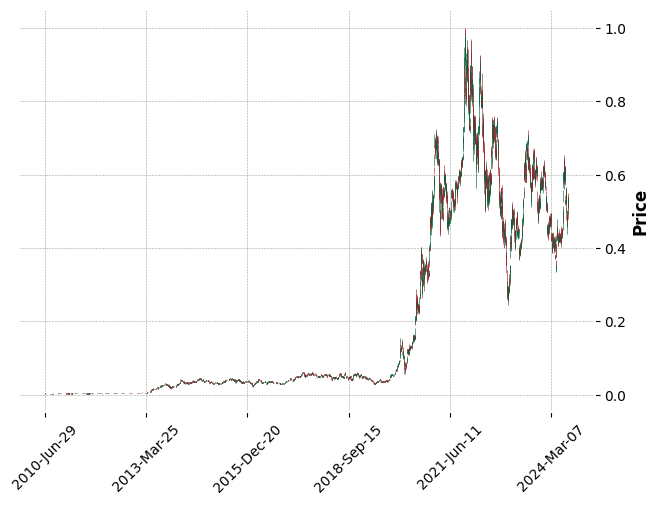

In [9]:
import pandas as pd
import mplfinance as mpf

# Supongamos que tienes un DataFrame 'df' con las siguientes columnas: 'Date', 'Open', 'High', 'Low', 'Close', 'Volume'
# Aquí hay un ejemplo de cómo podría verse:

df_rendimientos['Date'] = pd.to_datetime(df_rendimientos['Date'])
df_rendimientos.set_index('Date', inplace=True)

# Crear el gráfico de velas
mpf.plot(df_rendimientos, type='candle', volume=False, style='charles')


In [10]:
df_rendimientos

,t,Open,High,Low,Close,Volume,rendimiento
Date,,,,,,,
2010-06-29,-4934,0.003056,0.004021,0.002821,0.003842,0.306605,NaN
2010-06-30,-4933,0.004148,0.004893,0.003748,0.003833,0.280640,-0.002511
2010-07-01,-4932,0.004021,0.004169,0.003260,0.003532,0.133184,-0.078473
2010-07-02,-4931,0.003699,0.003715,0.003009,0.003088,0.082560,-0.125683
2010-07-03,-4930,0.003579,0.003591,0.002893,0.002964,0.089659,-0.040234
...,...,...,...,...,...,...,...
2024-08-18,230,0.518935,0.535396,0.513860,0.532019,0.086339,0.010077
2024-08-19,231,0.523695,0.537954,0.516506,0.537326,0.081834,0.009976
2024-08-20,232,0.542538,0.550595,0.529703,0.533418,0.079166,-0.007274


# Problema de las áreas

In [11]:
campos_modo_vela = {'area': ['Open', 'Close'], 'extremos': ['Low', 'High']}
modo_vela = 'area' # area o extremos


df = df_rendimientos[['t'] + campos_modo_vela[modo_vela]].reset_index()
df

,Date,t,Open,Close
0,2010-06-29,-4934,0.003056,0.003842
1,2010-06-30,-4933,0.004148,0.003833
2,2010-07-01,-4932,0.004021,0.003532
3,2010-07-02,-4931,0.003699,0.003088
4,2010-07-03,-4930,0.003579,0.002964
...,...,...,...,...
5164,2024-08-18,230,0.518935,0.532019
5165,2024-08-19,231,0.523695,0.537326
5166,2024-08-20,232,0.542538,0.533418
5167,2024-08-21,233,0.537206,0.538653


In [12]:
df_date = df[['Date', 't']]

In [13]:
X0 = df[['t', campos_modo_vela[modo_vela][0]]].rename(columns = {campos_modo_vela[modo_vela][0]: 'y'})
X1 = df[['t', campos_modo_vela[modo_vela][1]]].rename(columns = {campos_modo_vela[modo_vela][1]: 'y'})

X = pd.concat([X0, X1], axis = 0)
#X = X.rename(columns = {'t': 'x'}).reset_index(drop = True)
X # Toda la nube de puntos del problema

,t,y
0,-4934,0.003056
1,-4933,0.004148
2,-4932,0.004021
3,-4931,0.003699
4,-4930,0.003579
...,...,...
5164,230,0.532019
5165,231,0.537326
5166,232,0.533418
5167,233,0.538653


In [14]:
def crear_dic_t_incial(df, K):
    t_min, t_max = df['t'].min(), df['t'].max()
    dic_t = {}
    for k in range(K + 1):
        t = t_min + k * (t_max - t_min) / K
        dic_t[k] = round(t)
    return dic_t

In [15]:
import matplotlib.pyplot as plt

In [16]:
# Graficar los datos en X, pinta de un color distinto según k_grupo

def graficar(X, K, df_date, dic_puntos = {}, dic_t = {}, titulo = ""):
    
    X = X.merge(df_date, on = 't', how = 'left')
    
    if len(dic_t) > 0:
        X['k'] = X['t'].apply(lambda t: sum([t >= dic_t[k] for k in range(K)])) # Cuantas veces supera límites inferiores = Grupo
        X = X.sort_values(by = 't').reset_index(drop = True)
        
    plt.figure(figsize = (10, 5))
    grupos = X['k'].unique()
    for k in grupos:
        X_k = X[X['k'] == k]
        plt.plot(X_k['Date'], X_k['y'], 'o', label = f'Grupo {k}', c = plt.cm.tab20(k), markersize = 2) # markersize: tamaño de los puntos
    
        if k not in dic_puntos:
            continue    
        B0L, B1L, B0U, B1U = dic_puntos[k]['B0L'], dic_puntos[k]['B1L'], dic_puntos[k]['B0U'], dic_puntos[k]['B1U']
        plt.plot([X_k['Date'].min(), X_k['Date'].max()], [B0L + B1L * X_k['t'].min(), B0L + B1L * X_k['t'].max()], c = 'r')
        plt.plot([X_k['Date'].min(), X_k['Date'].max()], [B0U + B1U * X_k['t'].min(), B0U + B1U * X_k['t'].max()], c = 'g')
    
    if titulo != "":
        plt.title(titulo)
    plt.show()

In [17]:
import mip
# 1. generate_figure
def generate_all_figure(data_points, dic_t, gamma, output = True, slope_inf = 'libre', slope_sup = 'libre', paralelas = False, segmentos_conjuntos = True):

    '''
    :param data_points: Nube de puntos con los campos k | x | y, donde k es el grupo al que pertenece
    :param dic_t: Diccionario con los límites de los grupos
    :param gamma: Peso de las holguras
    :type: dataframe
    '''

    # CONFIGURACION
    
    # figura libre: libre, libre, False
    # canal: libre, libre, True
    # arriba pendiente 0: 0, libre, False
    # abajo pendiente 0: libre, 0, False
    # arriba y abajo pendiente 0: 0, 0, False/True

    output_vars = False
    data_points = data_points.reset_index(drop = True)
    
    grupos = data_points['k'].unique()
    
    mip_model = mip.Model()
    # Variables
    variables = {}
    for k in grupos:
        for v in ['B0L', 'B1L', 'B0U', 'B1U', 'HU', 'HL']: # HU & HL son las holguras en los grupos
            if v in ['HU', 'HL']:
                variables[f'G{k}_{v}'] = mip_model.add_var(var_type = 'C', name = f'G{k}_{v}') # C: Continuas >= 0
            else:
                variables[f'G{k}_{v}'] = mip_model.add_var(var_type = 'C', name = f'G{k}_{v}', lb = - float('inf')) 
        
    # Restriccion de puntos
    for k in grupos:
        data_k = data_points[data_points['k'] == k].reset_index(drop = True)
        for i in range(len(data_k)):
            t, y = data_k['t'][i], data_k['y'][i]
            #y = data_k['y'][i]
            
            variables[f'G{k}_HU_{i}'] = mip_model.add_var(var_type = 'C', name = f'G{k}_HU_{i}') # C: Continuas
            variables[f'G{k}_HL_{i}'] = mip_model.add_var(var_type = 'C', name = f'G{k}_HL_{i}') # C: Continuas

            R1 = (variables[f'G{k}_B0U'] + variables[f'G{k}_B1U'] * t >= y - variables[f'G{k}_HU_{i}']) # Se incluyen las holguras
            R2 = (variables[f'G{k}_B0L'] + variables[f'G{k}_B1L'] * t <= y + variables[f'G{k}_HL_{i}'])
            
            # independiente de las holguras, la recta superior debeestar siempre sobre la inferior
            R3 = (variables[f'G{k}_B0U'] + variables[f'G{k}_B1U'] * t >= variables[f'G{k}_B0L'] + variables[f'G{k}_B1L'] * t)
            
            mip_model += R1
            mip_model += R2
            mip_model += R3


    # Restricciones de figuras
    if slope_inf == '0':
        for k in grupos:
            R4A = (variables[f'G{k}_B1L'] == 0)
            mip_model += R4A
    if slope_sup == '0':
        for k in grupos:
            R4B = (variables[f'G{k}_B1U'] == 0)
            mip_model += R4B
    if paralelas:
        for k in grupos:
            R4C = (variables[f'G{k}_B1L'] == variables[f'G{k}_B1U'])
            mip_model += R4C
            
    # Restricciones de segmentos conjuntos
    
    #sys.exit()
    for k in grupos:
        if not segmentos_conjuntos:
            break
        if k == max(grupos): # EL último límite no es contemplado
            break
        
        R5 = (variables[f'G{k}_B0L'] + variables[f'G{k}_B1L'] * dic_t[k] == variables[f'G{k + 1}_B0L'] + variables[f'G{k + 1}_B1L'] * dic_t[k])
        mip_model += R5
        R6 = (variables[f'G{k}_B0U'] + variables[f'G{k}_B1U'] * dic_t[k] == variables[f'G{k + 1}_B0U'] + variables[f'G{k + 1}_B1U'] * dic_t[k])
        mip_model += R6
    
    # Naturaleza de las variables de holgura
    """
    for k in grupos:
        data_k = data_points[data_points['k'] == k].reset_index(drop = True)
        for i in range(len(data_k)):
            R7 = (variables[f'G{k}_HU_{i}'] >= 0)
            mip_model += R7
            R8 = (variables[f'G{k}_HL_{i}'] >= 0)
            mip_model += R8
    """
        
    # Holgura total
    for k in grupos:
        data_k = data_points[data_points['k'] == k].reset_index(drop = True)
        R9 = (variables[f'G{k}_HU'] == sum([variables[f'G{k}_HU_{i}'] for i in range(len(data_k))]))
        mip_model += R9
        R10 = (variables[f'G{k}_HL'] == sum([variables[f'G{k}_HL_{i}'] for i in range(len(data_k))]))
        mip_model += R10
    
    # Funcion objetivo (minimizar el area conjunta de de los trapecios formado (altura horizontal:h)) -> Min (base_left + base_right) * h / 2 
    Z = 0
    for k in grupos:
        t0, tf = dic_t[k - 1], dic_t[k]
        base_left = variables[f'G{k}_B0U'] + variables[f'G{k}_B1U'] * t0 - (variables[f'G{k}_B0L'] + variables[f'G{k}_B1L'] * t0)
        base_right = variables[f'G{k}_B0U'] + variables[f'G{k}_B1U'] * tf - (variables[f'G{k}_B0L'] + variables[f'G{k}_B1L'] * tf)
        Z_k = (base_left + base_right) * (tf - t0) / 2 + gamma * (variables[f'G{k}_HU'] + variables[f'G{k}_HL'])
        Z += Z_k

    mip_model.objective = mip.minimize(Z)
    mip_model.verbose = 0 # Para no generar outputs de la librería mip
    status = mip_model.optimize()

    if (status == mip.OptimizationStatus.OPTIMAL) and output:
        print(f'AREA: Función objetivo: {mip_model.objective_value} óptima encontrada')
    elif (status == mip.OptimizationStatus.FEASIBLE) and output:
        print(f'Solución factible {mip_model.objective_value} encontrada (gap), mejor posible: {mip_model.objective_bound}')
    elif (status == mip.OptimizationStatus.NO_SOLUTION_FOUND) and output:
        print(f'Solución infactible, Solución RMIP: {mip_model.objective_bound}')

    if status == mip.OptimizationStatus.OPTIMAL or status == mip.OptimizationStatus.FEASIBLE:
        for v in variables:
            
            if (variables[v].x == 0) and ('HL_' in v or 'HU_' in v):
                continue
            variables[v] = [variables[v].x]
            if output_vars:
                print(f'{v} = {variables[v][0]}')

        df_variables = pd.DataFrame(variables)
        return df_variables, mip_model.objective_value

    else:
        print('Error en factibilidad del modelo')
        return pd.DataFrame({}), float('inf')

In [18]:
from sympy import *

# FUNCION OBJETIVO GENERAL
def update_dic_t(K, dic_puntos, gamma_value, dic_holguras, learning_rate = 10 ** 17):
    #beta0L, beta1L, beta0U, beta1U, t, A, gamma, R1, R2, B1, B2, H, i, N = symbols("beta0L beta1L beta0U beta1U t A gamma R1 R2 B1 B2 H i N")
    gamma = symbols("gamma")

    B1, B2, H, A, Holguras = {}, {}, {}, {}, {}
    S = 0
    #K = 2
    for k in range(1, K + 1):
        print(k)
        B1[k] = (Indexed('beta0U', k) + Indexed('beta1U', k) * Indexed('t', k - 1)) - (Indexed('beta0L', k) + Indexed('beta1L', k) * Indexed('t', k - 1))
        B2[k] = (Indexed('beta0U', k) + Indexed('beta1U', k) * Indexed('t', k)) - (Indexed('beta0L', k) + Indexed('beta1L', k) * Indexed('t', k))
        H[k] = Indexed('t', k) - Indexed('t', k - 1)
        A[k] = (B1[k] + B2[k]) * H[k] / 2
        Holguras[k] = gamma * (Indexed('R1', k) + Indexed('R2', k))
        S += (A[k] + Holguras[k])

    # eval en S (se reemplazan los valores de las variables beta, gamma y Holguras (R))

    for k in range(1, K + 1):
        S = S.evalf(subs = {Indexed('beta0L', k): dic_puntos[k]['B0L'], # Recta inf
                        Indexed('beta1L', k): dic_puntos[k]['B1L'], 
                        Indexed('beta0U', k): dic_puntos[k]['B0U'], # Recta sup
                        Indexed('beta1U', k): dic_puntos[k]['B1U'], 
                        gamma: gamma_value, # gamma
                        Indexed('R1', k): dic_holguras[k]['HL'], # Holguras
                        Indexed('R2', k): dic_holguras[k]['HU']})

    # Gradient Descent
    
    for k in range(1, K):
        D = diff(S, Indexed('t', k))
        D = D.evalf(subs = {Indexed('t', k): dic_t[k]})
        print(D)
        
        dic_t[k] = int(round(dic_t[k] - learning_rate * D))
    
    return dic_t

def update_dic_t_v1(i, K, iters, dic_puntos, output = False):
    # update_dic_t_v1

    delta_x = 1 # Si hay señal de movimiento, cuanto debe al menos moverse (hacia la izquierda o derecha) el t
    delta_min_x = 0 # que tan cerca se permite estar un t, del siguiente (t + 1)
    df_lambda = pd.DataFrame()

    #print('K y dic_puntos')
    for k in range(1, K):
        #print(k)
        #print(dic_puntos)
        m = ((dic_puntos[k]['B1U'] - dic_puntos[k]['B1L']) + (dic_puntos[k + 1]['B1U'] - dic_puntos[k + 1]['B1L'])) / 2
        df_lambda = pd.concat([df_lambda, pd.DataFrame({'t': [k], 'lambda': [m]})])
    #print('')

    # i es el índice de la iteración..podemos definir la cantidad de puntos t a "mover" según la iteración

    n_puntos_t = round((K - 1) * (1 - i / iters)) # N es la cantidad de iteraciones
    n_puntos_t = K - 1

    # de dic_lambda, elige 
    df_lambda['abs'] = df_lambda['lambda'].abs()
    df_lambda = df_lambda.sort_values(by = 'abs', ascending = False).reset_index(drop = True)
    if n_puntos_t == 0:
        display('df_lambda')
        display(df_lambda)
        r_lambda = 0
    else:
        r_lambda = df_lambda['abs'][n_puntos_t - 1] - 0.00001 # este es el criterio de movilidad final


    # Modelo de optimización

    mip_model = mip.Model()
    # Variables
    variables = {}
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'w', linea = f'INICIO  \n\n')

    for t in range(K + 1):
        variables[f'x_{t}'] = mip_model.add_var(var_type = 'C', name = f'x_{t}', lb = -float('inf')) # C: Continuas
        variables[f'alpha_{t}'] = mip_model.add_var(var_type = 'C', name = f'alpha_{t}') # C: Continuas
        variables[f'tnew_{t}'] = mip_model.add_var(var_type = 'C', name = f'tnew_{t}', lb = -float('inf')) # C: Continuas
        """
        R0 = (variables[f'alpha_{t}'] >= 0)
        
        #if rest0:
        #    mip_model += R0
        #    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 alpha ({t}): {R0}  \n\n')
        """
        
        if t in [0, K]: # Los extremos no se mueven
            R0 = (variables[f'x_{t}'] == 0)
            R1 = (variables[f'tnew_{t}'] == dic_t[t])
            
            mip_model += R0
            escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')
            mip_model += R1
            escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R1 t ({t}): {R1}  \n\n')
            
            continue
        
        _lambda = df_lambda[df_lambda['t'] == t]['lambda'].reset_index(drop = True)[0]

        if _lambda > r_lambda:
            #variables[f'x_{t}'].ub = - delta_x
            R0 = (variables[f'x_{t}'] <= - delta_x)       
            mip_model += R0
            escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')

            
        elif _lambda < - r_lambda:
            R0 = (variables[f'x_{t}'] >= delta_x)
            mip_model += R0
            escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')

        else:
            R0 = (variables[f'x_{t}'] == 0)        
            mip_model += R0
            escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')
            
        R1 = (variables[f'tnew_{t}'] == variables[f'x_{t}'] + dic_t[t])
        mip_model += R1
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R1 t ({t}): {R1}  \n\n')
            
        #escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'V ({t}): {R2}  \n\n')



    # Restricción de secuencialidad
    for t in range(K):
        R2 = (variables[f'tnew_{t}'] + delta_min_x <= variables[f'tnew_{t + 1}'])

        mip_model += R2
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R2 ({t}): {R2}  \n\n')

    # Restricción de "paso"
    for t in range(1, K):
        variables[f'x_up{t}'] = mip_model.add_var(var_type = 'C', name = f'x_up{t}') # C: Continuas (Holguras, solo para impedir infactibilidades)
        variables[f'x_down{t}'] = mip_model.add_var(var_type = 'C', name = f'x_down{t}') # C: Continuas
        
        _lambda = df_lambda[df_lambda['t'] == t]['lambda'].reset_index(drop = True)[0]
        R3 = (variables[f'x_{t}'] == - variables[f'alpha_{t}'] * _lambda + variables[f'x_up{t}'] - variables[f'x_down{t}']) 

        mip_model += R3
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R3 ({t}): {R3}  \n\n')

    # R4: Alpha total
    variables[f'alpha_T'] = mip_model.add_var(var_type = 'C', name = f'alpha_T') # C: Continuas
    # todos los alpha t tienen que ser <= a alphaT
    for t in range(K + 1):
        R4 = (variables[f'alpha_{t}'] <= variables[f'alpha_T'])

        mip_model += R4
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R4 ({t}): {R4}  \n\n')

    # Función objetivo: minimiza la suma de Holguras x_up+ x_down
    Z = 0
    for t in range(1, K):
        Z += variables[f'x_up{t}'] + variables[f'x_down{t}']

    # ahora multiipica por un valor grande y sumale alpha_T
    Z = (10 ** 10) * Z + variables[f'alpha_T']
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'Z: {Z}  \n\n')

    # print todo el detalle del modelo: variables, restricciones, función objetivo
    mip_model.objective = mip.minimize(Z)
    #mip_model.verbose = 0 # Para no generar outputs de la librería mip
    status = mip_model.optimize()
    status

    output_vars = False
    mip_model.objective = mip.minimize(Z)
    mip_model.verbose = 0 # Para no generar outputs de la librería mip
    status = mip_model.optimize()

    if (status == mip.OptimizationStatus.OPTIMAL) and output:
        print(f'Función objetivo: {mip_model.objective_value} óptima encontrada')
    elif (status == mip.OptimizationStatus.FEASIBLE)and output:
        print(f'Solución factible {mip_model.objective_value} encontrada (gap), mejor posible: {mip_model.objective_bound}')
    elif (status == mip.OptimizationStatus.NO_SOLUTION_FOUND)and output:
        print(f'Solución infactible, Solución RMIP: {mip_model.objective_bound}')

    if status == mip.OptimizationStatus.OPTIMAL or status == mip.OptimizationStatus.FEASIBLE:
        for v in variables:
            
            if (variables[v].x == 0) and ('HL_' in v or 'HU_' in v):
                continue
            variables[v] = [variables[v].x]
            if output_vars:
                print(f'{v} = {variables[v][0]}')
            
            if 'tnew' in v:
                dic_t[int(v.split('_')[1])] = round(variables[v][0], 4)

        df_variables = pd.DataFrame(variables)
        #return df_variables, mip_model.objective_value
        return dic_t

    else:
        print('Error en factibilidad del modelo')
        print(mip.OptimizationStatus)
    

In [19]:
def escribir_modelo_opt(archivo, modo, linea, activar = True):
    if activar:
        with open(archivo, modo) as writefile:
            #print(linea)
            writefile.write(linea)
    
    
    return None

In [20]:
"""
# update_dic_t_v1

delta_x = 0.5
delta_min_x = 0.5
df_lambda = pd.DataFrame()

for k in range(1, K):
    #print(k)
    #print(dic_puntos)
    m = ((dic_puntos[k]['B1U'] - dic_puntos[k]['B1L']) + (dic_puntos[k + 1]['B1U'] - dic_puntos[k + 1]['B1L'])) / 2
    df_lambda = pd.concat([df_lambda, pd.DataFrame({'t': [k], 'lambda': [m]})])


# i es el índice de la iteración..podemos definir la cantidad de puntos t a "mover" según la iteración

n_puntos_t = round((K - 1) * (1 - i / iters)) # N es la cantidad de iteraciones

# de dic_lambda, elige 
df_lambda['abs'] = df_lambda['lambda'].abs()
df_lambda = df_lambda.sort_values(by = 'abs', ascending = False).reset_index(drop = True)
r_lambda = df_lambda['abs'][n_puntos_t - 1] - 0.00001 # este es el criterio de movilidad final


# Modelo de optimización

mip_model = mip.Model()
# Variables
variables = {}
escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'w', linea = f'INICIO  \n\n')

for t in range(K + 1):
    variables[f'x_{t}'] = mip_model.add_var(var_type = 'C', name = f'x_{t}', lb = -float('inf')) # C: Continuas
    variables[f'alpha_{t}'] = mip_model.add_var(var_type = 'C', name = f'alpha_{t}') # C: Continuas
    variables[f'tnew_{t}'] = mip_model.add_var(var_type = 'C', name = f'tnew_{t}', lb = -float('inf')) # C: Continuas
    
    #R0 = (variables[f'alpha_{t}'] >= 0)
    
    #if rest0:
    #    mip_model += R0
    #    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 alpha ({t}): {R0}  \n\n')

    
    if t in [0, K]: # Los extremos no se mueven
        R0 = (variables[f'x_{t}'] == 0)
        R1 = (variables[f'tnew_{t}'] == dic_t[t])
        
        mip_model += R0
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')
        mip_model += R1
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R1 t ({t}): {R1}  \n\n')
        
        continue
    
    _lambda = df_lambda[df_lambda['t'] == t]['lambda'].reset_index(drop = True)[0]

    if _lambda > r_lambda:
        #variables[f'x_{t}'].ub = - delta_x
        R0 = (variables[f'x_{t}'] <= - delta_x)       
        mip_model += R0
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')

        
    elif _lambda < - r_lambda:
        R0 = (variables[f'x_{t}'] >= delta_x)
        mip_model += R0
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')

    else:
        R0 = (variables[f'x_{t}'] == 0)        
        mip_model += R0
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')
        
    R1 = (variables[f'tnew_{t}'] == variables[f'x_{t}'] + dic_t[t])
    mip_model += R1
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R1 t ({t}): {R1}  \n\n')
        
    #escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'V ({t}): {R2}  \n\n')



# Restricción de secuencialidad
for t in range(K):
    R2 = (variables[f'tnew_{t}'] + delta_min_x <= variables[f'tnew_{t + 1}'])

    mip_model += R2
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R2 ({t}): {R2}  \n\n')

# Restricción de "paso"
for t in range(1, K):
    variables[f'x_up{t}'] = mip_model.add_var(var_type = 'C', name = f'x_up{t}') # C: Continuas (Holguras, solo para impedir infactibilidades)
    variables[f'x_down{t}'] = mip_model.add_var(var_type = 'C', name = f'x_down{t}') # C: Continuas
    
    _lambda = df_lambda[df_lambda['t'] == t]['lambda'].reset_index(drop = True)[0]
    R3 = (variables[f'x_{t}'] == - variables[f'alpha_{t}'] * _lambda + variables[f'x_up{t}'] - variables[f'x_down{t}']) 

    mip_model += R3
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R3 ({t}): {R3}  \n\n')

# R4: Alpha total
variables[f'alpha_T'] = mip_model.add_var(var_type = 'C', name = f'alpha_T') # C: Continuas
# todos los alpha t tienen que ser <= a alphaT
for t in range(K + 1):
    R4 = (variables[f'alpha_{t}'] <= variables[f'alpha_T'])

    mip_model += R4
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R4 ({t}): {R4}  \n\n')

# Función objetivo: minimiza la suma de Holguras x_up+ x_down
Z = 0
for t in range(1, K):
    Z += variables[f'x_up{t}'] + variables[f'x_down{t}']

# ahora multiipica por un valor grande y sumale alpha_T
Z = (10 ** 10) * Z + variables[f'alpha_T']
escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'Z: {Z}  \n\n')

# print todo el detalle del modelo: variables, restricciones, función objetivo
mip_model.objective = mip.minimize(Z)
#mip_model.verbose = 0 # Para no generar outputs de la librería mip
status = mip_model.optimize()
status

output_vars = False
mip_model.objective = mip.minimize(Z)
mip_model.verbose = 0 # Para no generar outputs de la librería mip
status = mip_model.optimize()

if (status == mip.OptimizationStatus.OPTIMAL):
    print(f'Función objetivo: {mip_model.objective_value} óptima encontrada')
elif (status == mip.OptimizationStatus.FEASIBLE):
    print(f'Solución factible {mip_model.objective_value} encontrada (gap), mejor posible: {mip_model.objective_bound}')
elif (status == mip.OptimizationStatus.NO_SOLUTION_FOUND):
    print(f'Solución infactible, Solución RMIP: {mip_model.objective_bound}')

if status == mip.OptimizationStatus.OPTIMAL or status == mip.OptimizationStatus.FEASIBLE:
    for v in variables:
        
        if (variables[v].x == 0) and ('HL_' in v or 'HU_' in v):
            continue
        variables[v] = [variables[v].x]
        if output_vars:
            print(f'{v} = {variables[v][0]}')
        
        if 'tnew' in v:
            dic_t[int(v.split('_')[1])] = round(variables[v][0], 4)

    df_variables = pd.DataFrame(variables)
    #return df_variables, mip_model.objective_value

else:
    print('Error en factibilidad del modelo')
    print(mip.OptimizationStatus)
"""

'\n# update_dic_t_v1\n\ndelta_x = 0.5\ndelta_min_x = 0.5\ndf_lambda = pd.DataFrame()\n\nfor k in range(1, K):\n    #print(k)\n    #print(dic_puntos)\n    m = ((dic_puntos[k][\'B1U\'] - dic_puntos[k][\'B1L\']) + (dic_puntos[k + 1][\'B1U\'] - dic_puntos[k + 1][\'B1L\'])) / 2\n    df_lambda = pd.concat([df_lambda, pd.DataFrame({\'t\': [k], \'lambda\': [m]})])\n\n\n# i es el índice de la iteración..podemos definir la cantidad de puntos t a "mover" según la iteración\n\nn_puntos_t = round((K - 1) * (1 - i / iters)) # N es la cantidad de iteraciones\n\n# de dic_lambda, elige \ndf_lambda[\'abs\'] = df_lambda[\'lambda\'].abs()\ndf_lambda = df_lambda.sort_values(by = \'abs\', ascending = False).reset_index(drop = True)\nr_lambda = df_lambda[\'abs\'][n_puntos_t - 1] - 0.00001 # este es el criterio de movilidad final\n\n\n# Modelo de optimización\n\nmip_model = mip.Model()\n# Variables\nvariables = {}\nescribir_modelo_opt(archivo = f\'Modelo de optimizacion A.txt\', modo = \'w\', linea = f\'INICI

# Modelo iterativo

In [21]:
#sys.exit('COntinuar aqui: Para K = 2...validar que el óptimo encontrado por el algorítmo está cerca del óptimo real moviendo el t1 uno a uno de principio a fin')

In [22]:
# Algorítmo que generaliza los valores de dic_t

#rango = [-100, 100]
#K = 3
#paso = 2
def construir_df_t(rango, K, paso):
# los extremos son siempre fijos:
    df_t = pd.DataFrame({'t0': [rango[0]]})
    df_t['AUX'] = 'aux'

    for i in range(1, K):
        df_t_i = pd.DataFrame({f't{i}': range(rango[0], rango[1] + 1, paso)})
        df_t_i['AUX'] = 'aux'
        df_t = df_t.merge(df_t_i, on = 'AUX', how = 'left')
        #df_t = df_t.drop(columns = 'AUX')
        df_t = df_t[df_t[f't{i}'] > df_t[f't{i - 1}']].reset_index(drop = True)
        #break
    df_t = df_t.drop(columns = 'AUX')
    df_t[f't{K}'] = rango[1]
    df_t = df_t[df_t[f't{K}'] > df_t[f't{K - 1}']].reset_index(drop = True)
    return df_t


In [23]:
def update_dic_t_v1_5(df_t, i):
    for c in df_t.columns:
        dic_t[int(c[1:])] = df_t[c][i]
    return dic_t

In [24]:
# v3
#best_FO = 12.58243629
#dic_t_optimo = {0: -61.0, 1: 38.0, 2: 101.0, 3: 204.0}

In [25]:
import tqdm

In [26]:
def update_dic_t_v2(K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos, best_FO, t_no_considerar = -1, divisiones = 100):
    
    #best_FO = float('inf')
    best_FO_inicial = best_FO
    for t in range(1, K): # Para cada t intermedio
        
        if t == t_no_considerar: # Si es el último t que cambió, no se vuelve a evaluar
            continue
        #print('t en upd v2', t)
        lb, lu = dic_t[t - 1], dic_t[t + 1]
        rango = (lu - lb) / divisiones
        dic_t_aux = dic_t.copy()
        for r in range(1, divisiones): #tqdm.tqdm(range(1, divisiones)): # entre 1 y divisiones, no toma los valores de lu y lb
            value = lb + r * rango
            dic_t_aux[t] = value
            
            X['k'] = X['t'].apply(lambda t: sum([t >= dic_t_aux[k] for k in range(K)])) # Cuantas veces supera límites inferiores = Grupo
            X['k'] = X['k'].astype(int)
            X = X.sort_values(by = 't').reset_index(drop = True)
        
            df_resultados, FO = generate_all_figure(X, dic_t_aux, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
            
            if FO < best_FO:
                df_resultados_optimo = df_resultados.copy()
                best_FO = FO
                dic_t_optimo = dic_t_aux.copy()
                t_optimo = t
                X_optimo = X.copy()

    if best_FO == best_FO_inicial:
        return dic_t, pd.DataFrame(), 0, 0, X, True
    
    return dic_t_optimo, df_resultados_optimo, best_FO, t_optimo, X_optimo, False
    

    

In [27]:
def update_dic_t_v2_v2(K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos, best_FO, t_considerar, divisiones = 100):
    
    #best_FO = float('inf')
    best_FO_inicial = best_FO
    for t in range(1, K): # Para cada t intermedio
        
        if t not in t_considerar: # Solo se evaluarán (salvo en la primera iteración, el anterior y el siguiente al último t de cambio)
            continue
        
        print('t en upd v2', t)
        lb, lu = dic_t[t - 1], dic_t[t + 1]
        rango = (lu - lb) / divisiones
        dic_t_aux = dic_t.copy()
        for r in tqdm.tqdm(range(1, divisiones)): # entre 1 y divisiones, no toma los valores de lu y lb
            value = lb + r * rango
            dic_t_aux[t] = value
            
            X['k'] = X['t'].apply(lambda t: sum([t >= dic_t_aux[k] for k in range(K)])) # Cuantas veces supera límites inferiores = Grupo
            X['k'] = X['k'].astype(int)
            X = X.sort_values(by = 't').reset_index(drop = True)
        
            df_resultados, FO = generate_all_figure(X, dic_t_aux, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
            
            if FO < best_FO:
                df_resultados_optimo = df_resultados.copy()
                best_FO = FO
                dic_t_optimo = dic_t_aux.copy()
                t_optimo = t
                X_optimo = X.copy()

    if best_FO == best_FO_inicial:
        return dic_t, pd.DataFrame(), 0, 0, X, True
    
    print('')
    print('Nuevo t óptimo:', t_optimo)
    return dic_t_optimo, df_resultados_optimo, best_FO, t_optimo, X_optimo, False
    

    

In [28]:
def restricciones_v0(version, dic_t):
    
    if version != 'v0':
        return dic_t
    for t in dic_t:
        if t == 0:
            dic_t[0] = t_min
        elif dic_t[t] <= dic_t[t - 1]:
            dic_t[t] = dic_t[t - 1] + 1
    # Lo mismo al inverso
    for t in reversed(dic_t):
        if t == K:
            dic_t[K] = t_max
        elif dic_t[t] >= dic_t[t + 1]:
            dic_t[t] = dic_t[t + 1] - 1
    return dic_t
    

In [29]:
def corregir_X(X, dic_t):
    # Restricción 2A y 3A
    X['k'] = X['t'].apply(lambda t: sum([t >= dic_t[k] for k in range(K)])) # Cuantas veces supera límites inferiores = Grupo
    X['k'] = X['k'].astype(int)
    X = X.sort_values(by = 't').reset_index(drop = True)
    return X

In [30]:
def obtener_puntos(df_resultados):
    dic_puntos, dic_holguras = {}, {}
    for k in range(1, K + 1):
        dic_puntos[k] = {'B0L': df_resultados[f'G{k}_B0L'][0], 'B1L': df_resultados[f'G{k}_B1L'][0], 'B0U': df_resultados[f'G{k}_B0U'][0], 'B1U': df_resultados[f'G{k}_B1U'][0]}
        dic_holguras[k] = {'HU': df_resultados[f'G{k}_HU'][0], 'HL': df_resultados[f'G{k}_HL'][0]}
    return dic_puntos, dic_holguras

In [31]:
def Modelo_chartista(version, K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos, iters = 100):
    paso_grafico = 0
    df_z = pd.DataFrame()
    best_FO = float('inf')
    all_results = set()

    if version == 'v1_5':
        paso = 10
        df_t = construir_df_t([dic_t[0], dic_t[K]], K, paso)
        iters = len(df_t)

    if version == 'v2':
        t_no_considerar = -1 # Por defecto
        
    X = X.rename(columns = {'k_grupo': 'k'})
        
    for i in range(iters): #tqdm.tqdm(range(iters)):
        
        dic_t = restricciones_v0(version, dic_t) # Restricción 3B
        
        if version not in [ "v2"]:
            
            X = corregir_X(X, dic_t)
            df_resultados, FO = generate_all_figure(X, dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
            dic_puntos, dic_holguras = obtener_puntos(df_resultados)
            if FO < best_FO:
                best_dic_t = dic_t.copy()
                best_FO = FO
                
        if version == 'v0':
            dic_t = update_dic_t(K, dic_puntos, gamma_value, dic_holguras) # funcion objetivo y gradient descent
        elif version == 'v1': # descenso del gradiente simple
            dic_t = update_dic_t_v1(i, K, iters, dic_puntos) # funcion objetivo y gradient descent # otimización en gradientes---movimientos idealmente proporcionales al gradiente
            #X = corregir_X(X, dic_t)
            #df_resultados, FO = generate_all_figure(X, dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
            #dic_puntos, dic_holguras = obtener_puntos(df_resultados)
            
        elif version == 'v1_5': 
            dic_t = update_dic_t_v1_5(df_t, i) # prueba con pasos de fuerza bruta (muchas iteraciones)
        elif version == 'v2': # cada t no extremo, se mueve entre el t anterior y el siguiente
            dic_t, df_resultados, FO, t_no_considerar, X, optimo_encontrado = update_dic_t_v2(K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos, best_FO, t_no_considerar = t_no_considerar)
            if optimo_encontrado:
                best_dic_t = dic_t.copy()
                best_FO = FO
                print('optimo_encontrado')
                break
            
            # Obtener dic_puntos para gráficar
            dic_puntos, dic_holguras = obtener_puntos(df_resultados)
        
        if (paso_grafico != 0) and (i % paso_grafico == 0):
            graficar(X, K, dic_puntos)
        
        if version != "v1":
            if FO < best_FO:
                best_dic_t = dic_t.copy()
                best_FO = FO
                #best_dic_puntos = dic_puntos.copy()
        
        df_z_new = pd.DataFrame({'iter': [i], 'FO': [FO]})
        df_z = pd.concat([df_z, df_z_new], axis = 0)
        
        res = ''
        for j in list(dic_t.values()):
            res += str(j) + '_'
        res += str(round(FO, 4))
        
        if res in all_results:
            print('Ya se ha encontrado este ciclo...comenzaría a hacer un loop')
            print(dic_t)
            print(all_results)
            break
        
        all_results.add(res)
        
        #print('Best FO', best_FO, best_dic_t)

    return best_dic_t, best_FO, df_z
    



In [32]:
def Modelo_chartista_v2(version, K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos, iters = 100):
    
    criterio_convergencia = 0.0005
    
    if version != "v2":
        sys.exit('Solo se puede usar la versión v2')
    paso_grafico = 0
    df_z = pd.DataFrame()
    best_FO = float('inf')
    all_results = set()

    t_considerar = list(range(1, K)) # Por defecto
        
    X = X.rename(columns = {'k_grupo': 'k'})
        
    for i in range(iters): #tqdm.tqdm(range(iters)):

        # cada t no extremo, se mueve entre el t anterior y el siguiente
        dic_t, df_resultados, FO, t_optimo_iteracion, X, optimo_encontrado = update_dic_t_v2_v2(K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos, best_FO, t_considerar)
        t_considerar = [t_optimo_iteracion - 1, t_optimo_iteracion + 1]
        if optimo_encontrado:
            best_dic_t = dic_t.copy()
            best_FO = FO
            print('optimo_encontrado')
            break
            
            # Obtener dic_puntos para gráficar
            dic_puntos, dic_holguras = obtener_puntos(df_resultados)
        
        if (paso_grafico != 0) and (i % paso_grafico == 0):
            graficar(X, K, dic_puntos)
        
        if FO < best_FO:
            best_dic_t = dic_t.copy()
            
            if -(FO - best_FO) / best_FO < criterio_convergencia:
                break
            best_FO = FO
            #best_dic_puntos = dic_puntos.copy()
        
        df_z_new = pd.DataFrame({'iter': [i], 'FO': [FO]})
        df_z = pd.concat([df_z, df_z_new], axis = 0)
        
        res = ''
        for j in list(dic_t.values()):
            res += str(j) + '_'
        res += str(round(FO, 4))
        
        if res in all_results:
            print('Ya se ha encontrado este ciclo...comenzaría a hacer un loop')
            print(dic_t)
            print(all_results)
            break
        
        all_results.add(res)
        
        #print('Best FO', best_FO, best_dic_t)

    return best_dic_t, best_FO, df_z
    



# Iteraciones

In [33]:
import time

In [34]:
X

,t,y
0,-4934,0.003056
1,-4933,0.004148
2,-4932,0.004021
3,-4931,0.003699
4,-4930,0.003579
...,...,...
5164,230,0.532019
5165,231,0.537326
5166,232,0.533418
5167,233,0.538653


In [35]:
#sys.exit()

t en upd v2 1


100%|██████████| 99/99 [03:38<00:00,  2.20s/it]



Nuevo t óptimo: 1
optimo_encontrado


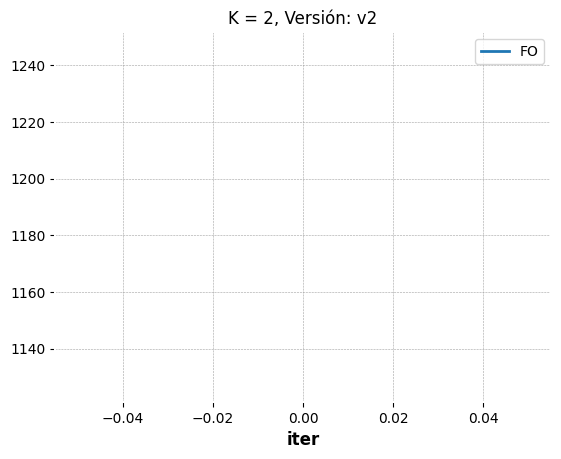

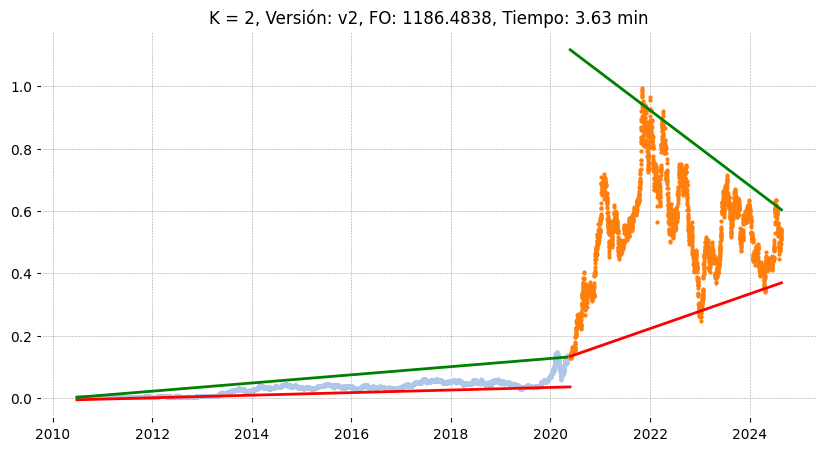

t en upd v2 1


100%|██████████| 99/99 [03:00<00:00,  1.82s/it]


t en upd v2 2


100%|██████████| 99/99 [03:51<00:00,  2.33s/it]



Nuevo t óptimo: 2
t en upd v2 1


...


Nuevo t óptimo: 2
t en upd v2 1


100%|██████████| 99/99 [03:21<00:00,  2.04s/it]



Nuevo t óptimo: 1
t en upd v2 2


100%|██████████| 99/99 [03:44<00:00,  2.26s/it]


optimo_encontrado


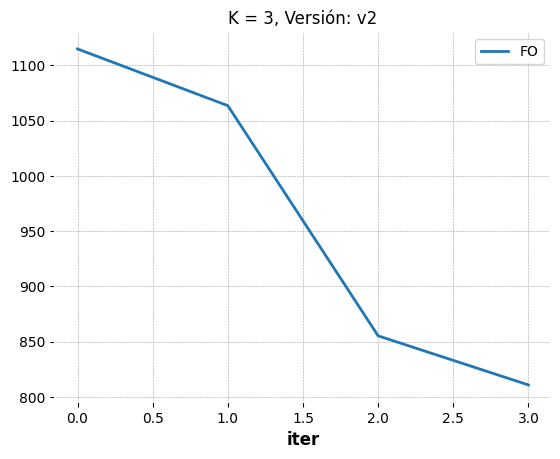

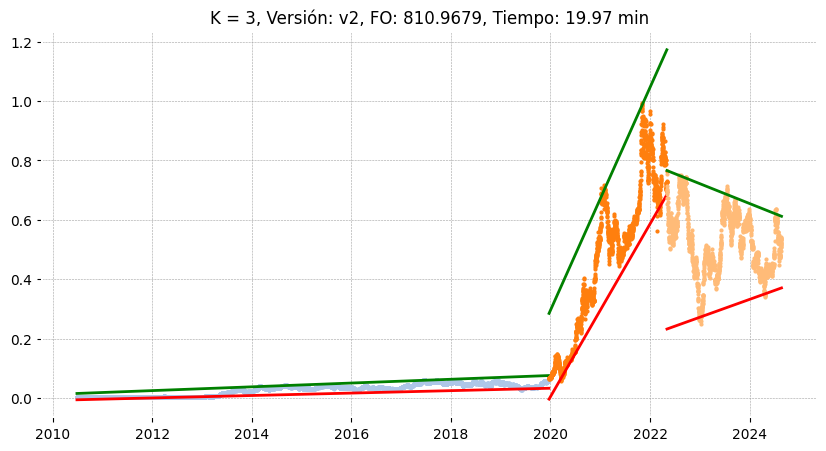

t en upd v2 1


100%|██████████| 99/99 [03:31<00:00,  2.13s/it]


t en upd v2 2


100%|██████████| 99/99 [03:33<00:00,  2.15s/it]


t en upd v2 3


...

t en upd v2 3


100%|██████████| 99/99 [03:18<00:00,  2.01s/it]



Nuevo t óptimo: 1
t en upd v2 2


100%|██████████| 99/99 [03:29<00:00,  2.11s/it]


optimo_encontrado


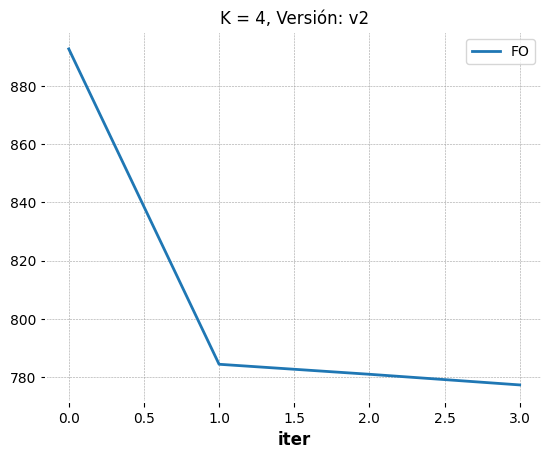

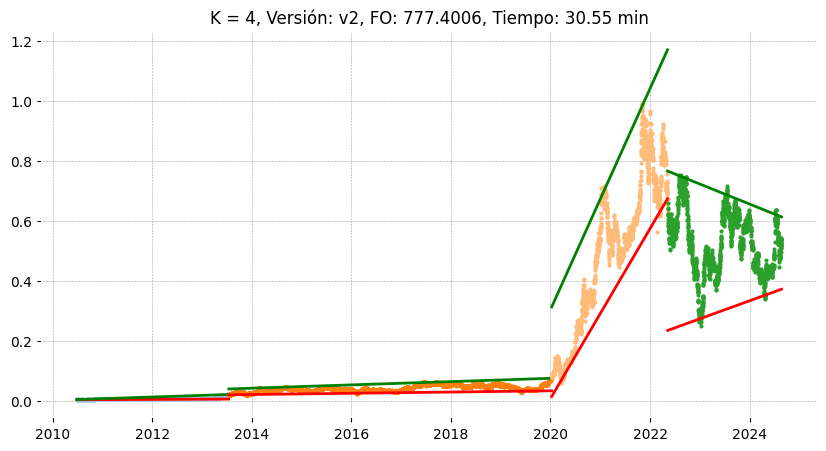

t en upd v2 1


100%|██████████| 99/99 [03:11<00:00,  1.93s/it]


t en upd v2 2


100%|██████████| 99/99 [03:18<00:00,  2.00s/it]


t en upd v2 3


...

t en upd v2 3


100%|██████████| 99/99 [03:09<00:00,  1.91s/it]



Nuevo t óptimo: 1
t en upd v2 2


100%|██████████| 99/99 [03:07<00:00,  1.90s/it]


optimo_encontrado


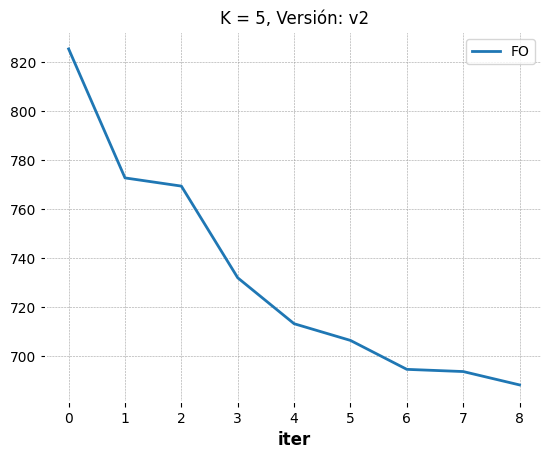

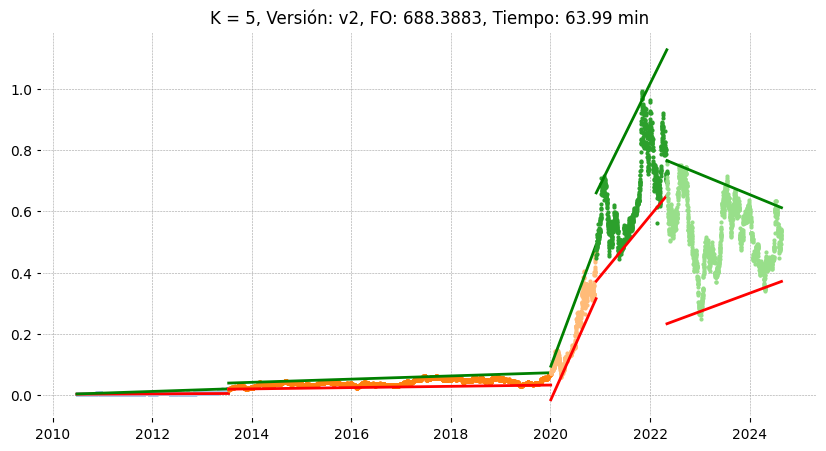

t en upd v2 1


100%|██████████| 99/99 [03:01<00:00,  1.84s/it]


t en upd v2 2


100%|██████████| 99/99 [03:01<00:00,  1.84s/it]


t en upd v2 3


...


Nuevo t óptimo: 3
t en upd v2 2


100%|██████████| 99/99 [02:55<00:00,  1.77s/it]


t en upd v2 4


100%|██████████| 99/99 [02:50<00:00,  1.72s/it]



Nuevo t óptimo: 2


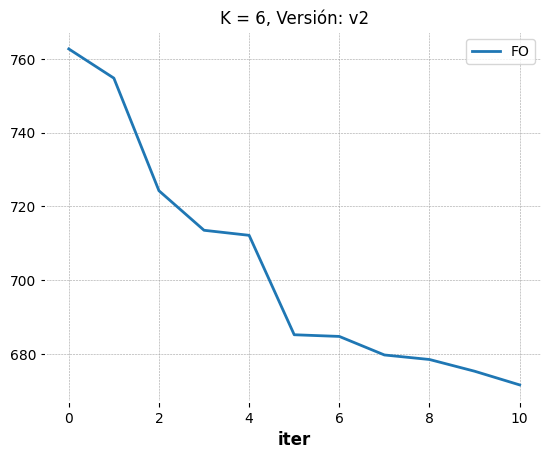

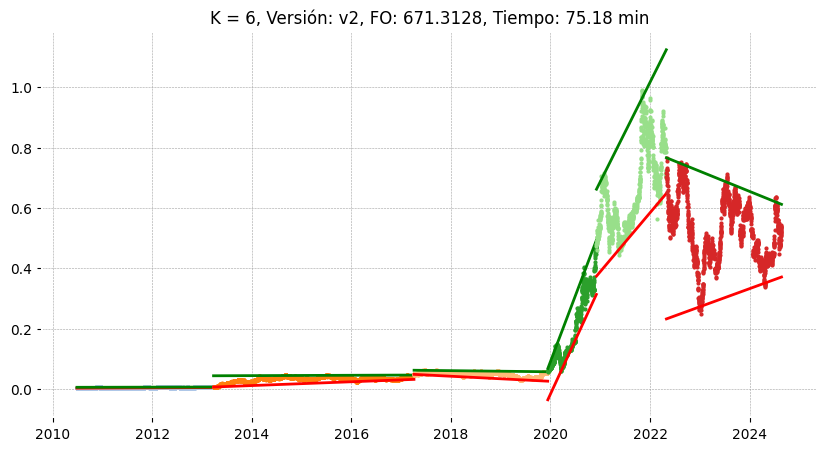

t en upd v2 1


100%|██████████| 99/99 [03:00<00:00,  1.82s/it]


t en upd v2 2


100%|██████████| 99/99 [03:01<00:00,  1.83s/it]


t en upd v2 3


...


Nuevo t óptimo: 5
t en upd v2 4


100%|██████████| 99/99 [02:17<00:00,  1.39s/it]


t en upd v2 6


100%|██████████| 99/99 [02:15<00:00,  1.37s/it]



Nuevo t óptimo: 6


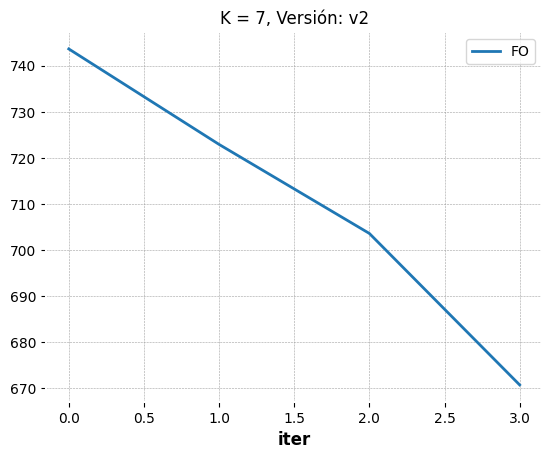

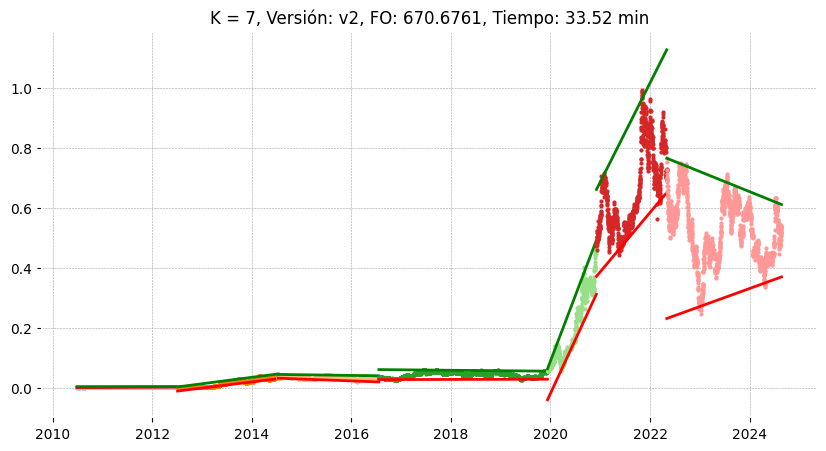

t en upd v2 1


100%|██████████| 99/99 [02:10<00:00,  1.32s/it]


t en upd v2 2


100%|██████████| 99/99 [02:08<00:00,  1.30s/it]


t en upd v2 3


...

t en upd v2 7


100%|██████████| 99/99 [03:00<00:00,  1.82s/it]



Nuevo t óptimo: 7
t en upd v2 6


100%|██████████| 99/99 [02:50<00:00,  1.72s/it]


optimo_encontrado


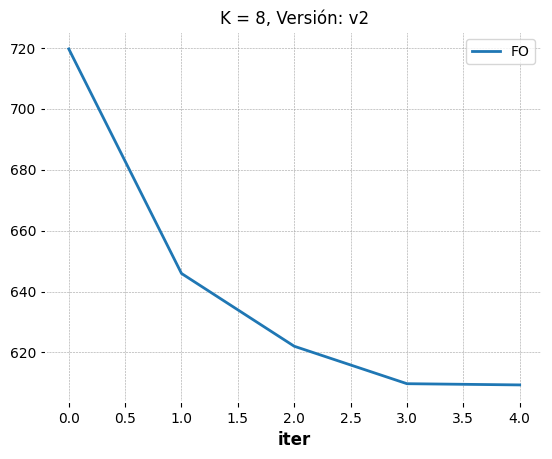

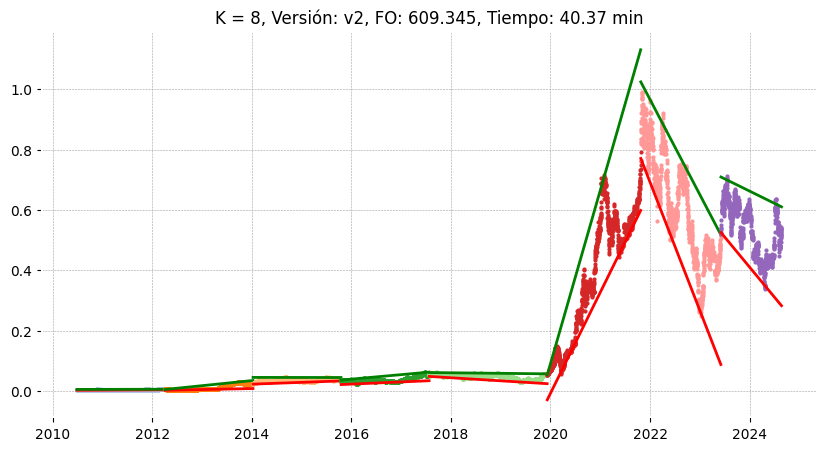

t en upd v2 1


100%|██████████| 99/99 [02:58<00:00,  1.80s/it]


t en upd v2 2


100%|██████████| 99/99 [02:51<00:00,  1.74s/it]


t en upd v2 3


...

t en upd v2 8


100%|██████████| 99/99 [02:50<00:00,  1.72s/it]



Nuevo t óptimo: 8
t en upd v2 7


100%|██████████| 99/99 [02:42<00:00,  1.64s/it]


optimo_encontrado


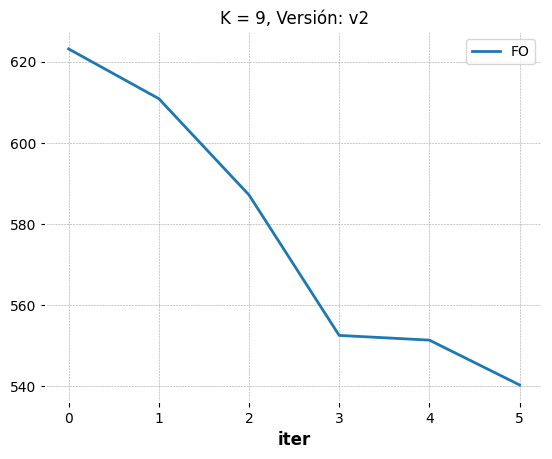

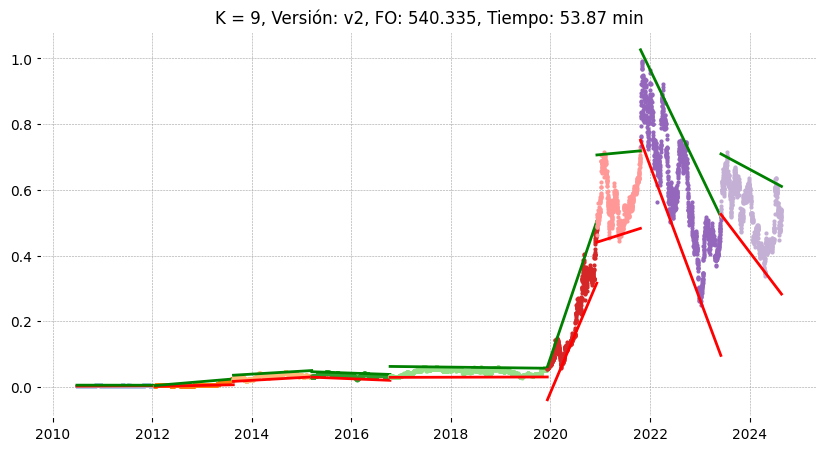

t en upd v2 1


100%|██████████| 99/99 [02:48<00:00,  1.70s/it]


t en upd v2 2


100%|██████████| 99/99 [02:45<00:00,  1.68s/it]


t en upd v2 3


...


Nuevo t óptimo: 7
t en upd v2 6


100%|██████████| 99/99 [02:47<00:00,  1.70s/it]


t en upd v2 8


100%|██████████| 99/99 [02:48<00:00,  1.71s/it]


optimo_encontrado


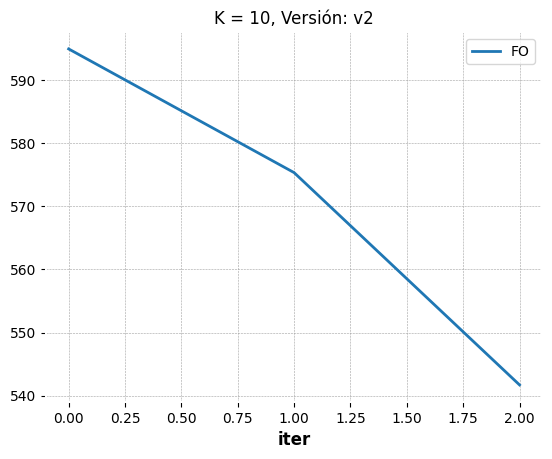

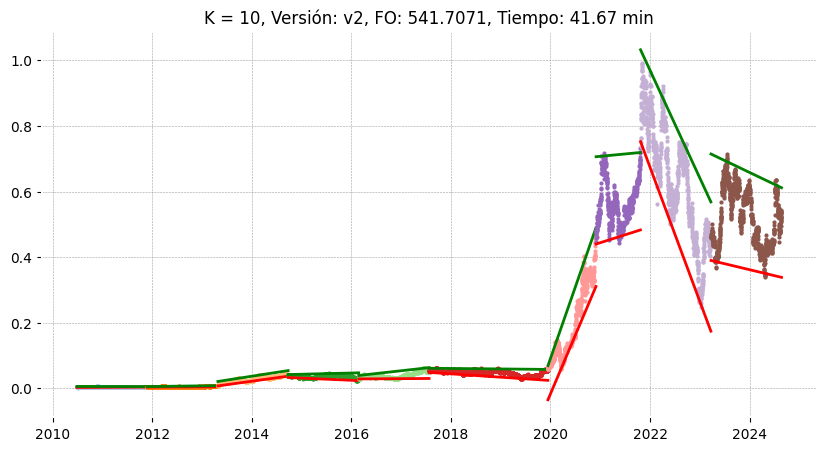

t en upd v2 1


100%|██████████| 99/99 [02:39<00:00,  1.61s/it]


t en upd v2 2


100%|██████████| 99/99 [02:39<00:00,  1.61s/it]


t en upd v2 3


...

t en upd v2 11


100%|██████████| 99/99 [02:46<00:00,  1.68s/it]



Nuevo t óptimo: 11
t en upd v2 10


100%|██████████| 99/99 [02:41<00:00,  1.63s/it]


optimo_encontrado


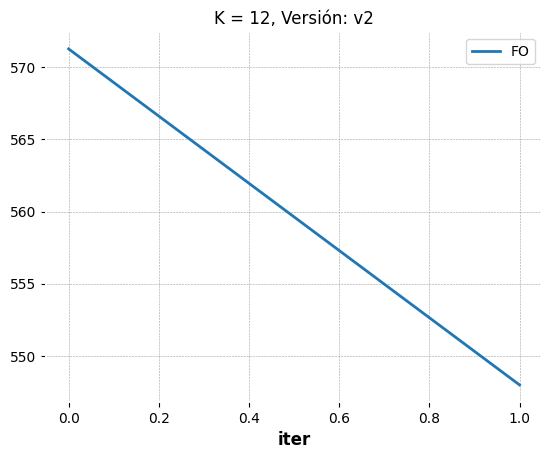

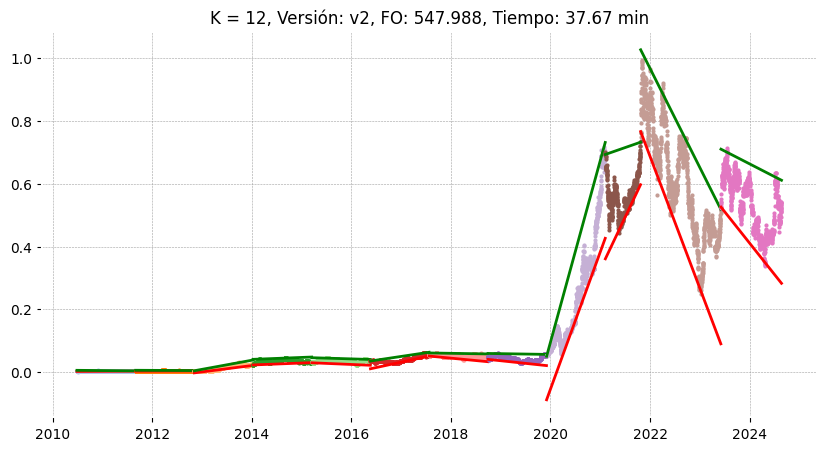

t en upd v2 1


100%|██████████| 99/99 [02:42<00:00,  1.64s/it]


t en upd v2 2


100%|██████████| 99/99 [02:44<00:00,  1.66s/it]


t en upd v2 3


...


Nuevo t óptimo: 8
t en upd v2 7


100%|██████████| 99/99 [02:44<00:00,  1.66s/it]


t en upd v2 9


100%|██████████| 99/99 [02:44<00:00,  1.66s/it]



Nuevo t óptimo: 9


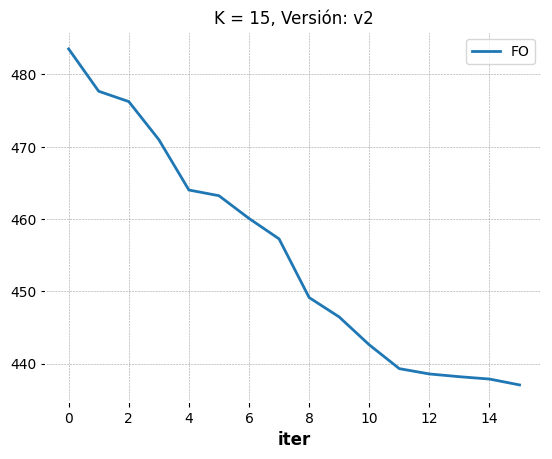

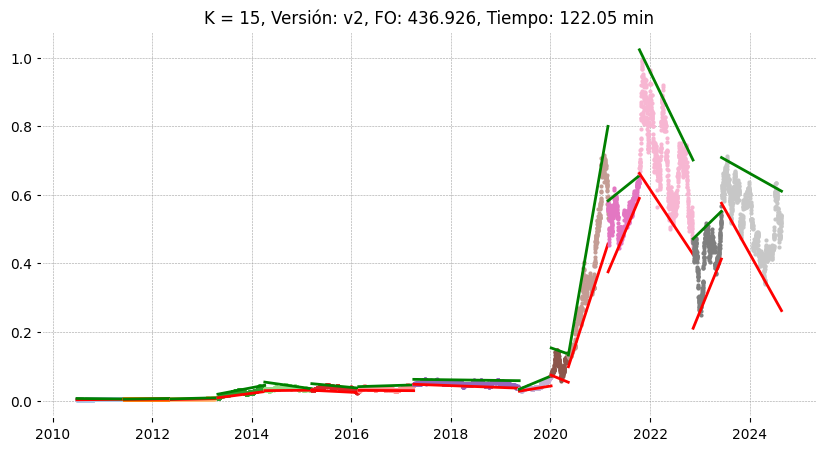

t en upd v2 1


100%|██████████| 99/99 [02:42<00:00,  1.64s/it]


t en upd v2 2


100%|██████████| 99/99 [02:40<00:00,  1.62s/it]


t en upd v2 3


...

t en upd v2 19


100%|██████████| 99/99 [02:49<00:00,  1.71s/it]



Nuevo t óptimo: 19
t en upd v2 18


100%|██████████| 99/99 [02:40<00:00,  1.62s/it]


optimo_encontrado


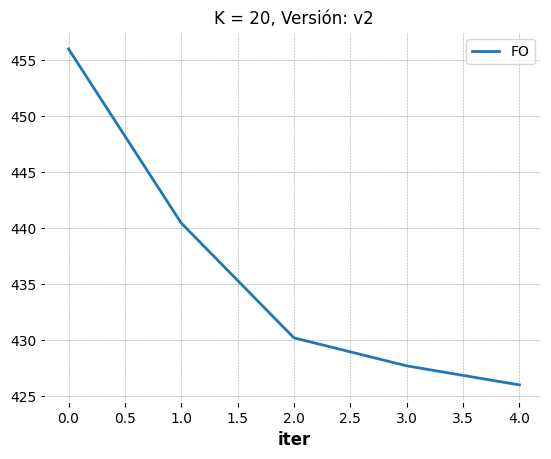

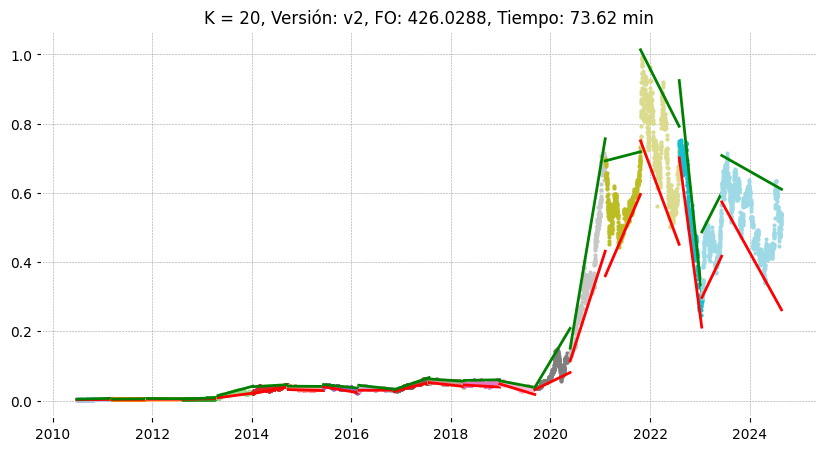

In [36]:
gamma_value = 50
paralelas = False
segmentos_conjuntos = False
df_all_results = pd.DataFrame()

for K in [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20]:
    dic_t = crear_dic_t_incial(df, K)
    for version in ['v2']: #['v1', 'v2']:
        t0 = time.time()
        best_dic_t, best_FO, df_z = Modelo_chartista_v2(version, K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos)
        t_all = (time.time() - t0) / 60
        # Mejor modelo
        df_z.plot(x = 'iter', y = 'FO', title = f'K = {K}, Versión: {version}') # plot F.O. evolución
        X = corregir_X(X, best_dic_t)
        
        #print('Best t optimo 1', best_FO,  best_dic_t)
        df_resultados, best_FO = generate_all_figure(X, best_dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
        dic_puntos, dic_holguras = obtener_puntos(df_resultados)
        #print('Best t optimo 2', best_FO,  best_dic_t)
        
        #print('Grafico óptimo')
        graficar(X, K, df_date, dic_puntos, titulo = f'K = {K}, Versión: {version}, FO: {round(best_FO, 4)}, Tiempo: {round(t_all, 2)} min')
        
        df_results_new = pd.DataFrame({'K': [K], 'Version': [version], 'FO': [best_FO], 'Tiempo': [t_all]})
        df_all_results = pd.concat([df_all_results, df_results_new], axis = 0)
        
        #sys.exit('Continuar acá 240725: Ejecutar todo de nuevo, eliminar tantas impresiones de gráficos y otras coasas e ir probando como se ven los resultados en cada iteración')
        

# Mejor modelo

In [37]:
sys.exit()

SystemExit: 

In [ ]:
best_dic_t

In [ ]:
# plotear df_z
df_z.plot(x = 'iter', y = 'FO')

In [ ]:
X['k'] = X['t'].apply(lambda t: sum([t >= best_dic_t[k] for k in range(K)])) # Cuantas veces supera límites inferiores = Grupo

#graficar(X, K)

# Continuar, encontrar B0L, B0U,1L, B1U para cada conjunto por separado, además de las holguras R1i, R2i (anclar 1)

# NUEVO: Encontrar B0L, B0U,1L, B1U para cada conjunto por separado, además de las holguras R1i, R2i (anclar 1)
#X = X.rename(columns = {'k_grupo': 'k'})
X['k'] = X['k'].astype(int)
X = X.sort_values(by = 't').reset_index(drop = True)

In [ ]:
df_resultados, FO = generate_all_figure(X, best_dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
FO


In [ ]:
dic_puntos, dic_holguras = {}, {}
for k in range(1, K + 1):
    dic_puntos[k] = {'B0L': df_resultados[f'G{k}_B0L'][0], 'B1L': df_resultados[f'G{k}_B1L'][0], 'B0U': df_resultados[f'G{k}_B0U'][0], 'B1U': df_resultados[f'G{k}_B1U'][0]}
    dic_holguras[k] = {'HU': df_resultados[f'G{k}_HU'][0], 'HL': df_resultados[f'G{k}_HL'][0]}
dic_puntos

In [ ]:
graficar(X, K, dic_puntos)

In [ ]:
sys.exit()

In [ ]:
# Mejores FOs algoritmo:

#k = 4 -> 11.1257579209791

In [ ]:
best_FO = 15.870443467963696
dic_t_optimo = {0: -61.0, 1: 35.0, 2: 204.0}

In [ ]:
# v3
best_FO = 12.58243629
dic_t_optimo = {0: -61.0, 1: 38.0, 2: 101.0, 3: 204.0}

In [ ]:
dic_t

In [ ]:
X['k'] = X['t'].apply(lambda t: sum([t >= dic_t[k] for k in range(K)]))

In [ ]:
[dic_t[k] for k in range(K)]

In [ ]:
X.info()

In [ ]:
X[X.index == 246]

In [ ]:
sys.exit()

# Antiguo

In [ ]:
# NUEVO: Encontrar B0L, B0U,1L, B1U para cada conjunto por separado, además de las holguras R1i, R2i (anclar 1)

gamma_value = 60
X = X.rename(columns = {'k_grupo': 'k'})
X['k'] = X['k'].astype(int)
X = X.sort_values(by = 't').reset_index(drop = True)
paralelas = False
segmentos_conjuntos = True

iters = 100
for i in range(iters):
    df_resultados = generate_all_figure(X, dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos)

    dic_puntos, dic_holguras = {}, {}
    for k in range(1, K + 1):
        dic_puntos[k] = {'B0L': df_resultados[f'G{k}_B0L'][0], 'B1L': df_resultados[f'G{k}_B1L'][0], 'B0U': df_resultados[f'G{k}_B0U'][0], 'B1U': df_resultados[f'G{k}_B1U'][0]}
        dic_holguras[k] = {'HU': df_resultados[f'G{k}_HU'][0], 'HL': df_resultados[f'G{k}_HL'][0]}
        #dic_puntos[k] = {'B0L': B0L, 'B1L': B1L, 'B0U': B0U, 'B1U': B1U}

    graficar(X, K, dic_puntos)
    dic_t = update_dic_t(K, dic_puntos, gamma_value, dic_holguras) # funcion objetivo y gradient descent

In [ ]:
# Continuar acá 240705: revisar codigo en: C:\Users\mvaldiviad\OneDrive - Falabella\Escritorio\Proyectos Personales\Apuestas Deportivas\teorico_mean_and_desv.ipynb para saber como usar sympy
# una vez encontradas, plantear la función objetivo solo en función de la variable t_k

# TO DO

# [OK] Continuar, encontrar B0L, B0U,1L, B1U para cada conjunto por separado, además de las holguras R1i, R2i

# [OK] revisar codigo en: C:\Users\mvaldiviad\OneDrive - Falabella\Escritorio\Proyectos Personales\Apuestas Deportivas\teorico_mean_and_desv.ipynb para saber como usar sympy

# [OK] una vez encontradas, plantear la función objetivo solo en función de la variable t_k

# [OK] Descenso del gradiente

# [Mejorar! no está convergiendo bien] Iterar hasta la convergencia (continuar aca el 240708)

# Revisar como cambia la FO, para distintos valores de K y gamma. Ver las rectas  y el cambio de FO, gráficamente


# Función objetivo general (antigua)

In [ ]:
from sympy import *

def update_dic_t(K, learning_rate = 0.01):
    #beta0L, beta1L, beta0U, beta1U, t, A, gamma, R1, R2, B1, B2, H, i, N = symbols("beta0L beta1L beta0U beta1U t A gamma R1 R2 B1 B2 H i N")
    gamma = symbols("gamma")

    B1, B2, H, A, Holguras = {}, {}, {}, {}, {}
    S = 0
    #K = 2
    for k in range(1, K + 1):
        print(k)
        B1[k] = (Indexed('beta0U', k) + Indexed('beta1U', k) * Indexed('t', k - 1)) - (Indexed('beta0L', k) + Indexed('beta1L', k) * Indexed('t', k - 1))
        B2[k] = (Indexed('beta0U', k) + Indexed('beta1U', k) * Indexed('t', k)) - (Indexed('beta0L', k) + Indexed('beta1L', k) * Indexed('t', k))
        H[k] = Indexed('t', k) - Indexed('t', k - 1)
        A[k] = (B1[k] + B2[k]) * H[k] / 2
        Holguras[k] = gamma * (Indexed('R1', k) + Indexed('R2', k))
        S += (A[k] + Holguras[k])

    # eval en S (se reemplazan los valores de las variables beta, gamma y Holguras (R))

    for k in range(1, K + 1):
        S = S.evalf(subs = {Indexed('beta0L', k): dic_puntos[k]['B0L'], # Recta inf
                        Indexed('beta1L', k): dic_puntos[k]['B1L'], 
                        Indexed('beta0U', k): dic_puntos[k]['B0U'], # Recta sup
                        Indexed('beta1U', k): dic_puntos[k]['B1U'], 
                        gamma: gamma_value, # gamma
                        Indexed('R1', k): dic_holguras[k]['HL'], # Holguras
                        Indexed('R2', k): dic_holguras[k]['HU']})

    # Gradient Descent
    
    for k in range(1, K):
        D = diff(S, Indexed('t', k))
        D = D.evalf(subs = {Indexed('t', k): dic_t[k]})
        print(D)
        
        dic_t[k] = dic_t[k] - learning_rate * D
    
    return dic_t



In [ ]:
sys.exit()

In [ ]:
# ANTIGUO: Continuar, encontrar B0L, B0U,1L, B1U para cada conjunto por separado, además de las holguras R1i, R2i (anclar 1)

dic_puntos = {}
gamma = 100

df_resultados = generate_all_figure(X, dic_t, gamma)
display(df_resultados)
for k in range(1, K + 1):
    dic_puntos[k] = {'B0L': df_resultados[f'G{k}_B0L'][0], 'B1L': df_resultados[f'G{k}_B1L'][0], 'B0U': df_resultados[f'G{k}_B0U'][0], 'B1U': df_resultados[f'G{k}_B1U'][0]}
    #dic_puntos[k] = {'B0L': B0L, 'B1L': B1L, 'B0U': B0U, 'B1U': B1U}

graficar(X, K, dic_puntos)

# TO DO

# Otros

In [ ]:
# 1. generate_figure (original, para un solo trapecio)
def generate_figure(data_points, output = True, slope_inf = 'libre', slope_sup = 'libre', paralelas = False):

    '''
    :param data_points: Nube de puntos con los campos x | y
    :type: dataframe
    '''

    # CONFIGURACION
    
    # figura libre: libre, libre, False
    # canal: libre, libre, True
    # arriba pendiente 0: 0, libre, False
    # abajo pendiente 0: libre, 0, False
    # arriba y abajo pendiente 0: 0, 0, False/True

    if (slope_inf == '0') and (slope_sup == '0'):
        variables = {'B0L': [data_points['y'].min()], 'B1L': [0], 'B0U': [data_points['y'].max()], 'B1U': [0]}
        df_variables = pd.DataFrame(variables)
        return df_variables

    data_points = data_points.reset_index(drop = True)
    
    mip_model = mip.Model()
    # Variables
    variables = {}
    for v in ['B0L', 'B1L', 'B0U', 'B1U']:
        variables[v] = mip_model.add_var(var_type = 'C', name = v)

    # Restriccion de puntos
    for i in range(len(data_points)):
        x, y = data_points['x'][i], data_points['y'][i]

        R1 = (variables['B0U'] + variables['B1U'] * x >= y)
        R2 = (variables['B0L'] + variables['B1L'] * x <= y)
        mip_model += R1
        mip_model += R2

    # Restricciones de figuras
    if slope_inf == '0':
        R3 = (variables['B1L'] == 0)
        mip_model += R3
    if slope_sup == '0':
        R4 = (variables['B1U'] == 0)
        mip_model += R4
    if paralelas:
        R5 = (variables['B1L'] == variables['B1U'])
        mip_model += R5

    # Funcion objetivo (minimizar el area del trapecio formado (altura horizontal:h)) -> Min (base_left + base_right) * h / 2 <-> Min (base_left + base_right)
    t0, tf = data_points['x'].min(), data_points['x'].max()
    base_left = variables['B0U'] + variables['B1U'] * t0 - (variables['B0L'] + variables['B1L'] * t0)
    base_right = variables['B0U'] + variables['B1U'] * tf - (variables['B0L'] + variables['B1L'] * tf)

    Z = base_left + base_right
    mip_model.objective = mip.minimize(Z)
    mip_model.verbose = 0 # Para no generar outputs de la librería mip
    status = mip_model.optimize()

    if (status == mip.OptimizationStatus.OPTIMAL) and output:
        print(f'Función objetivo: {mip_model.objective_value} óptima encontrada')
    elif (status == mip.OptimizationStatus.FEASIBLE) and output:
        print(f'Solución factible {mip_model.objective_value} encontrada (gap), mejor posible: {mip_model.objective_bound}')
    elif (status == mip.OptimizationStatus.NO_SOLUTION_FOUND) and output:
        print(f'Solución infactible, Solución RMIP: {mip_model.objective_bound}')

    if status == mip.OptimizationStatus.OPTIMAL or status == mip.OptimizationStatus.FEASIBLE:
        for v in variables:
            variables[v] = [variables[v].x]

        df_variables = pd.DataFrame(variables)
        return df_variables

    else:
        print('Error en factibilidad del modelo')
        return pd.DataFrame({})